In [177]:
from src.OLS import OLS
from src.stat_tests import RESET, VIF

import pandas as pd
import numpy as np

from scipy.stats import norm, t as t_dist

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

In [136]:
data_kw = {'encoding': 'utf-8', 'low_memory': False}

rgdp = pd.read_csv('data/fred/GDPC1.csv', **data_kw)
rgdp = rgdp.rename(columns={'GDPC1': 'Y'})

pce = pd.read_csv('data/fred/PCECC96.csv', **data_kw)
pce = pce.rename(columns={'PCECC96': 'pce'})

pdi = pd.read_csv('data/fred/GPDIC1.csv', **data_kw)
pdi = pdi.rename(columns={'GPDIC1': 'pdi'})

govexp = pd.read_csv('data/fred/GCEC1.csv', **data_kw)
govexp = govexp.rename(columns={'GCEC1': 'govexp'})

odef = pd.read_csv('data/fred/GDPDEF.csv', **data_kw)
odef = odef.rename(columns={'GDPDEF': 'odef'})

unat = pd.read_csv('data/fred/NROU.csv', **data_kw)
unat = unat.rename(columns={'NROU': 'u^*'})

unrate = pd.read_csv('data/fred/LRUN64TTUSQ156S.csv', **data_kw)
unrate = unrate.rename(columns={'LRUN64TTUSQ156S': 'u'})
ugap = pd.DataFrame(
    {
    "ugap": unrate['u'] - unat['u^*'],
    'observation_date': unrate['observation_date']
    }
)

gdp_pot = pd.read_csv('data/fred/GDPPOT.csv', **data_kw)
gdp_pot = gdp_pot.rename(columns={'GDPPOT': 'Y^*'})
ogap = pd.DataFrame({
    "ogap": np.log(rgdp['Y']) - np.log(gdp_pot['Y^*']),
    'observation_date': rgdp['observation_date']
})

netexp = pd.read_csv('data/fred/NETEXP.csv', **data_kw)
netexp['NETEXP'] = netexp['NETEXP'] / rgdp['Y']
# Interactions
okun = pd.DataFrame({
    "okun": ugap['ugap'] * ogap['ogap'],
    'observation_date': rgdp['observation_date']
})

phillips = pd.DataFrame({
    "phillips": ugap['ugap'] * np.log(odef['odef']).diff(),
    'observation_date': rgdp['observation_date']
})

In [137]:
set = [
    rgdp,
    pce,
    pdi,
    govexp,
    odef,
    # netexp,
    ugap,
    ogap,
    okun,
    phillips,
]
regressors = set[1:]
for df in set:
    df['observation_date'] = pd.to_datetime(df['observation_date'])
    df.set_index('observation_date', inplace=True)
target = np.log(rgdp).diff().dropna()

In [138]:

fmt_regressors = [
    np.log(pce).diff().loc[target.index],
    np.log(pdi).diff().loc[target.index],
    np.log(govexp).diff().loc[target.index],
    # netexp.diff().loc[target.index],
    ugap.loc[target.index],
    ogap.loc[target.index],
    okun.loc[target.index],
    phillips.loc[target.index],
]
X = pd.concat(fmt_regressors, axis=1).shift(1).dropna()
t_idx = X.index[:-21]
X = X.loc[t_idx]
y = target.loc[t_idx]
t_idx[-1]

Timestamp('2019-10-01 00:00:00')

In [139]:
fit = OLS(
    X=X.values,
    y=y.values.flatten(),
).fit(diagnosis_alpha=0.05, diagnosis_trend='n')
fit.error

R2: 0.3379
R2_ADJ: 0.2893
RMSE: 0.0047
MAPE: 0.95

In [140]:
RESET(
    X=X,
    y=y.values.flatten(),
    q=2
)

reject: False
pval: 0.2825920589955466
test_stat: 1.27865459595966
stat_name: RESET Test (F-Statistic)

In [141]:
t = {'_const': fit.T_tests[0]}
for i, var in enumerate(X.columns):
    t[var] = fit.T_tests[i+1]
t

{'_const': reject: False
 pval: 0.76426891362239
 test_stat: 0.3006236904720233
 stat_name: Coefficient Significance Test (T-Statistic),
 'pce': reject: True
 pval: 2.62961744823542e-7
 test_stat: 5.488221793614673
 stat_name: Coefficient Significance Test (T-Statistic),
 'pdi': reject: False
 pval: 0.0875873139735965
 test_stat: 1.7236128578055032
 stat_name: Coefficient Significance Test (T-Statistic),
 'govexp': reject: False
 pval: 0.262737118194336
 test_stat: 1.1257129899389757
 stat_name: Coefficient Significance Test (T-Statistic),
 'ugap': reject: False
 pval: 0.511085914995794
 test_stat: 0.659292366715311
 stat_name: Coefficient Significance Test (T-Statistic),
 'ogap': reject: False
 pval: 0.991710832545771
 test_stat: 0.010412758364400346
 stat_name: Coefficient Significance Test (T-Statistic),
 'okun': reject: False
 pval: 0.132942267633585
 test_stat: 1.5138092733794821
 stat_name: Coefficient Significance Test (T-Statistic),
 'phillips': reject: False
 pval: 0.152772516

In [142]:
fit.F_test

reject: True
pval: 2.2390174048148026e-07
test_stat: 6.954620457915336
stat_name: F Test (F-Statistic)

In [143]:
VIF(X)

array([1.30756869, 1.21233617, 1.36834631, 1.76353991, 1.79958732,
       2.56433413, 2.79913709])

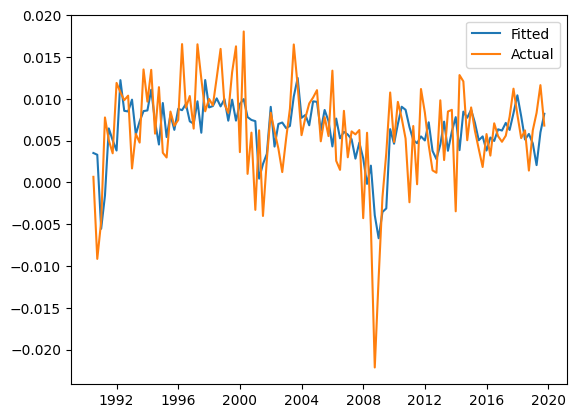

In [144]:
plt.plot(t_idx, fit.fitted_values, label='Fitted')
plt.plot(t_idx, y, label='Actual')
plt.legend()

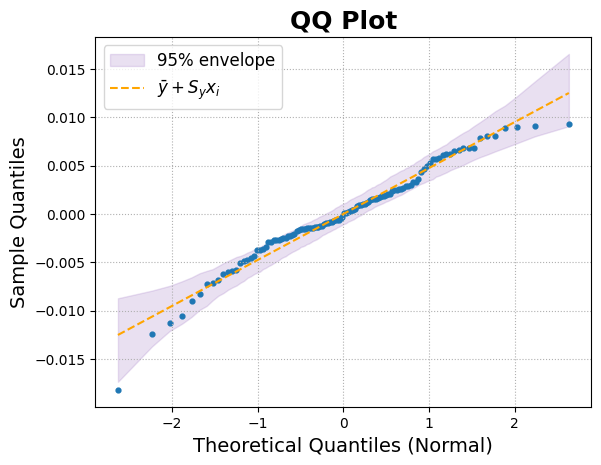

reject: True
pval: 0.010275926812120386
test_stat: 0.9703351267017377
stat_name: Shapiro-Wilk Test (Approximated Z-Statistic)

In [145]:
fit.qq(line='45')
fit.resid_normality

In [146]:
fit.coefs

array([ 5.75994898e-01,  2.88145953e-02, -8.43076522e-02,  2.37249869e-04,
       -5.14982058e-05,  5.41334830e-04, -8.46157054e-02])

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\s'
C:\Users\guney\AppData\Local\Temp\ipykernel_39224\1582744179.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax[i].plot(x, gaus_fit, label=f"Norm [$\mu={mu:,.2f}$, $\sigma={std:,.2f}$]")
C:\Users\guney\AppData\Local\Temp\ipykernel_39224\1582744179.py:16: SyntaxWarning: invalid escape sequence '\s'
  ax[i].plot(x, gaus_fit, label=f"Norm [$\mu={mu:,.2f}$, $\sigma={std:,.2f}$]")


Text(0.5, 0.98, 'Distributions of Regressors')

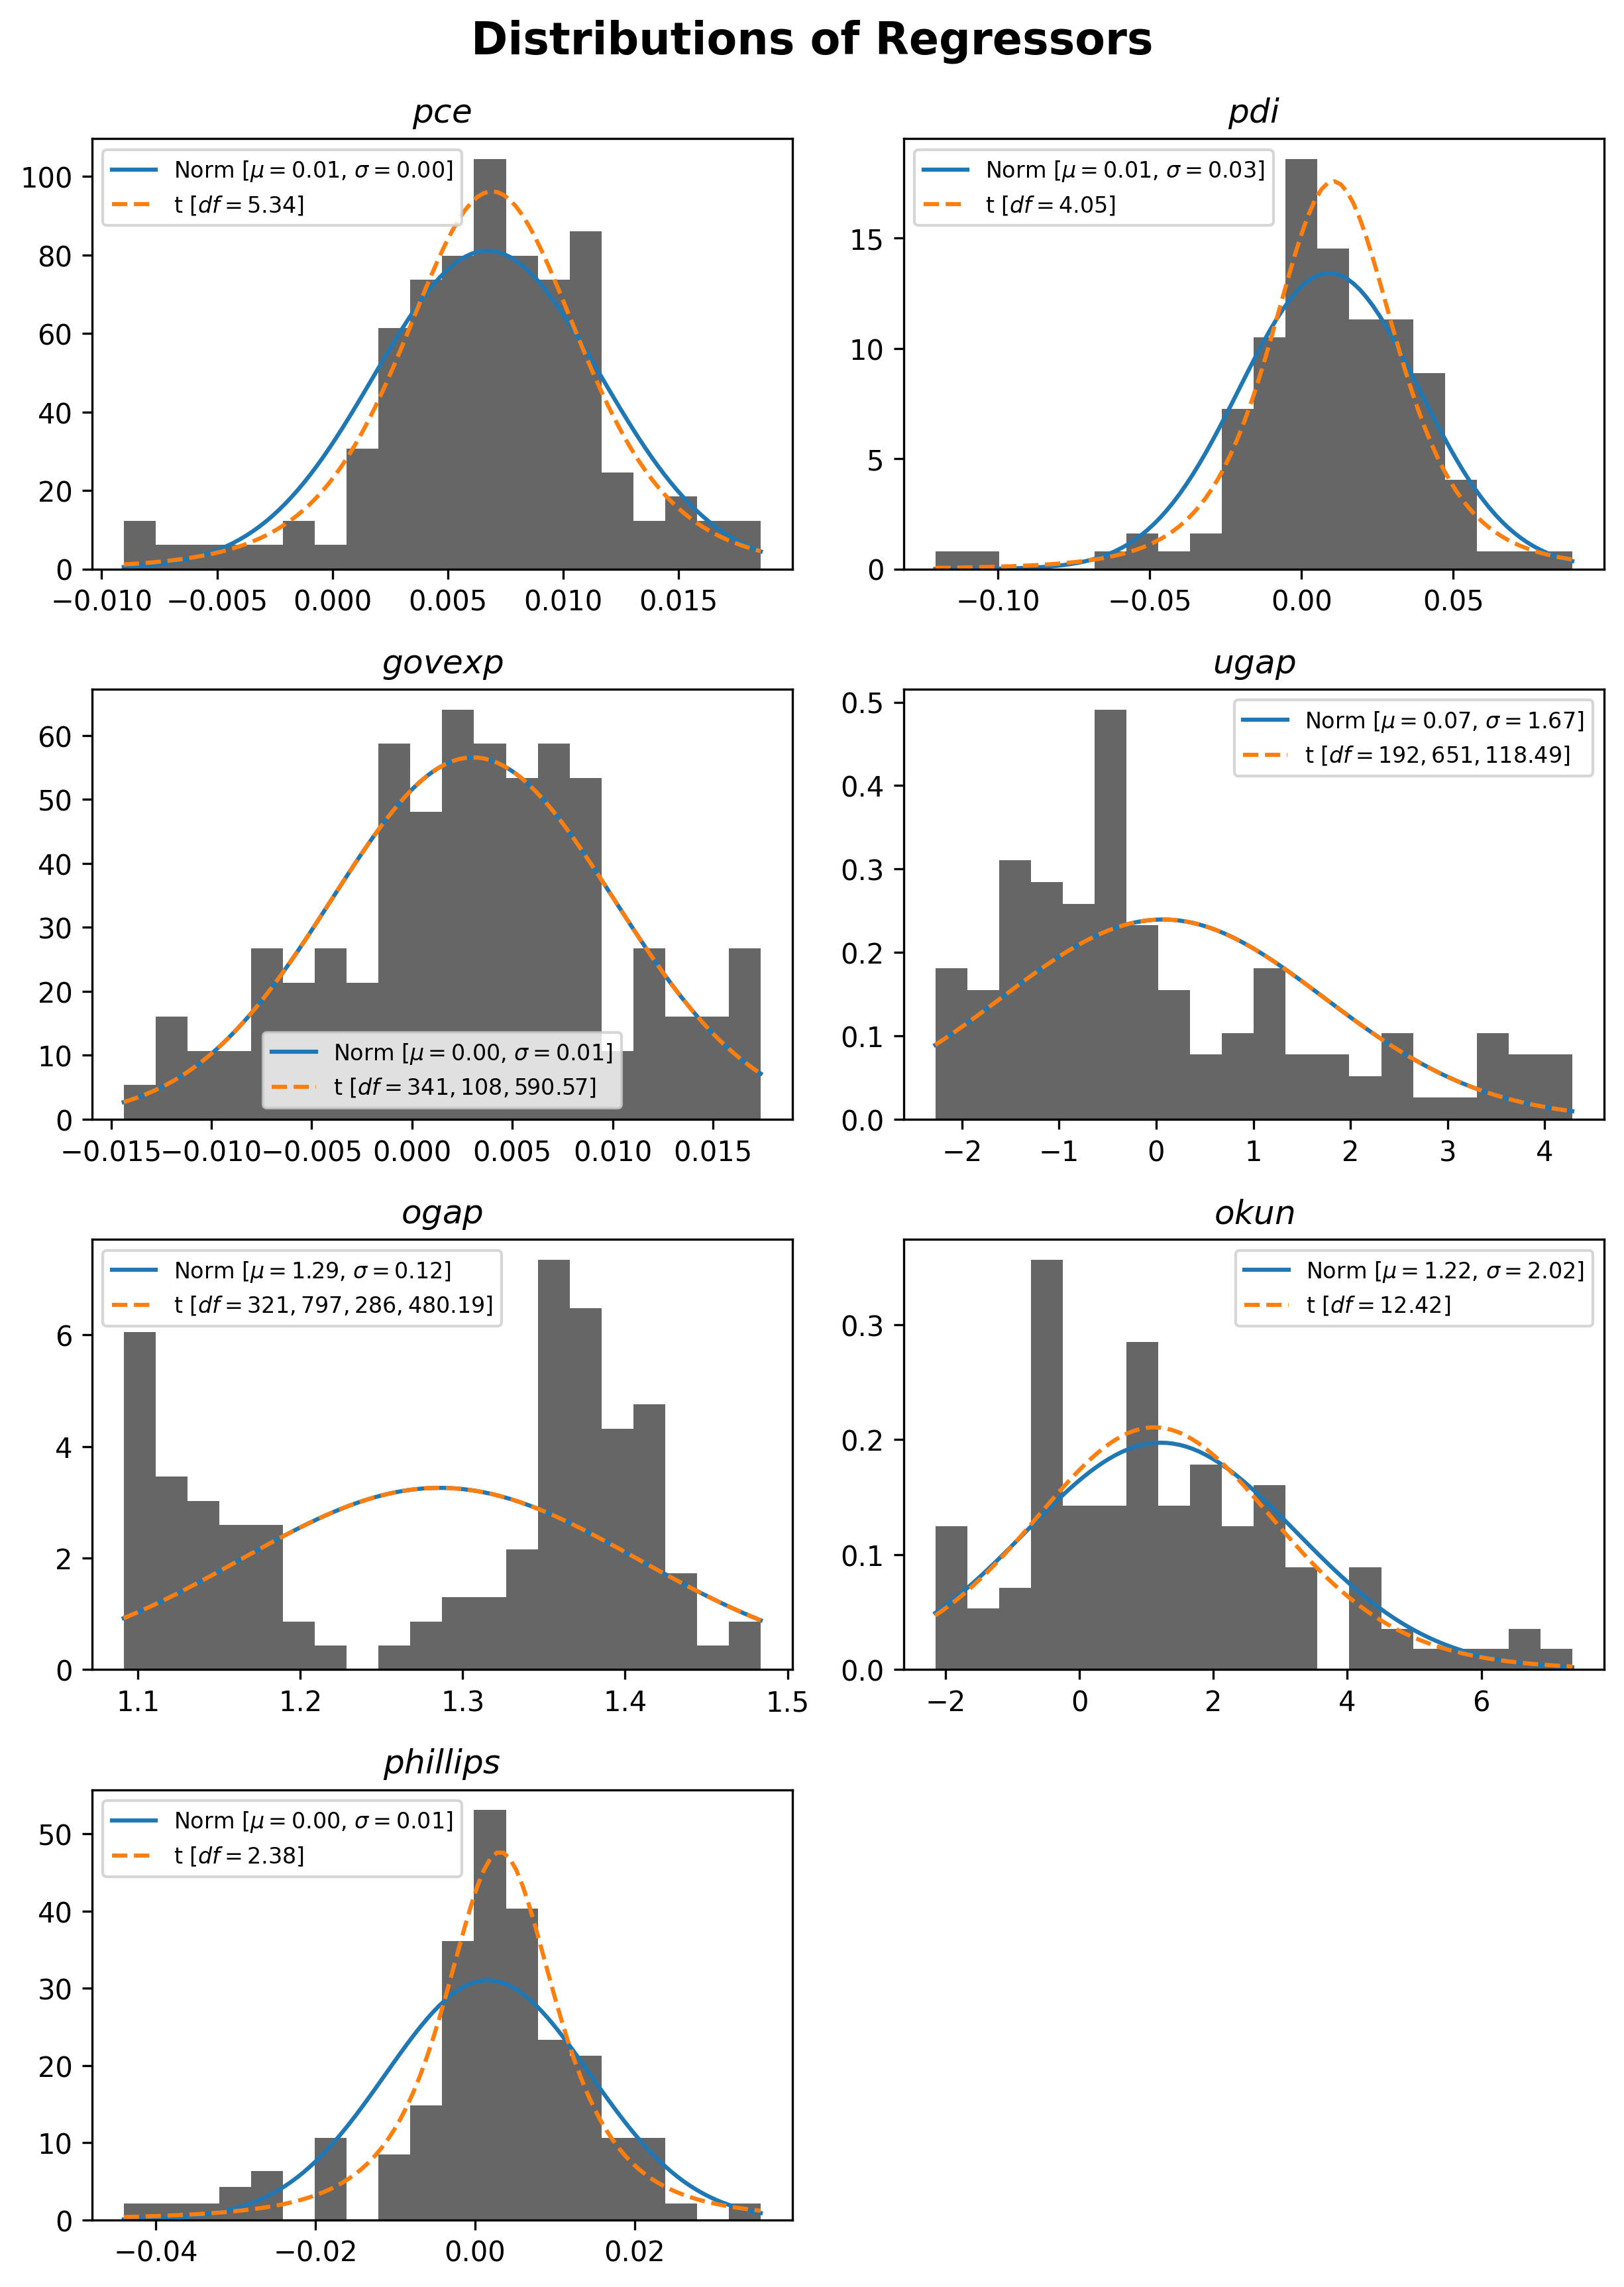

In [ ]:
fig, ax = plt.subplots(4, 2, figsize=(8.27, 11.69))
ax = ax.flatten()
while len(ax) > len(X.columns):
    fig.delaxes(ax[-1])
    ax = ax[:-1]

for i, v in enumerate(X.columns):
    ax[i].hist(X[v], bins=20, density=True, alpha=0.6, color='black')
    xmin, xmax = X[v].min(), X[v].max()
    x = np.linspace(xmin, xmax, 100)
    mu, std = norm.fit(X[v])
    gaus_fit = norm.pdf(x, mu, std)
    ts = t_dist.fit(X[v])
    t_fit = t_dist.pdf(x, *ts)

    ax[i].plot(x, gaus_fit, label=f"Norm [$\mu={mu:,.2f}$, $\sigma={std:,.2f}$]")
    ax[i].plot(x, t_fit, label=f"t [$df={ts[0]:,.2f}$]", linestyle='--')
    ax[i].set_title(fr"${v}$")
    ax[i].legend(fontsize=8, loc='best')
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.suptitle("Distributions of Regressors", fontsize=16, weight='bold')

In [199]:
target

,Y
observation_date,
1990-04-01,0.003623
1990-07-01,0.000666
1990-10-01,-0.009146
1991-01-01,-0.004690
1991-04-01,0.007767
...,...
2024-01-01,0.002096
2024-04-01,0.008816
2024-07-01,0.008214


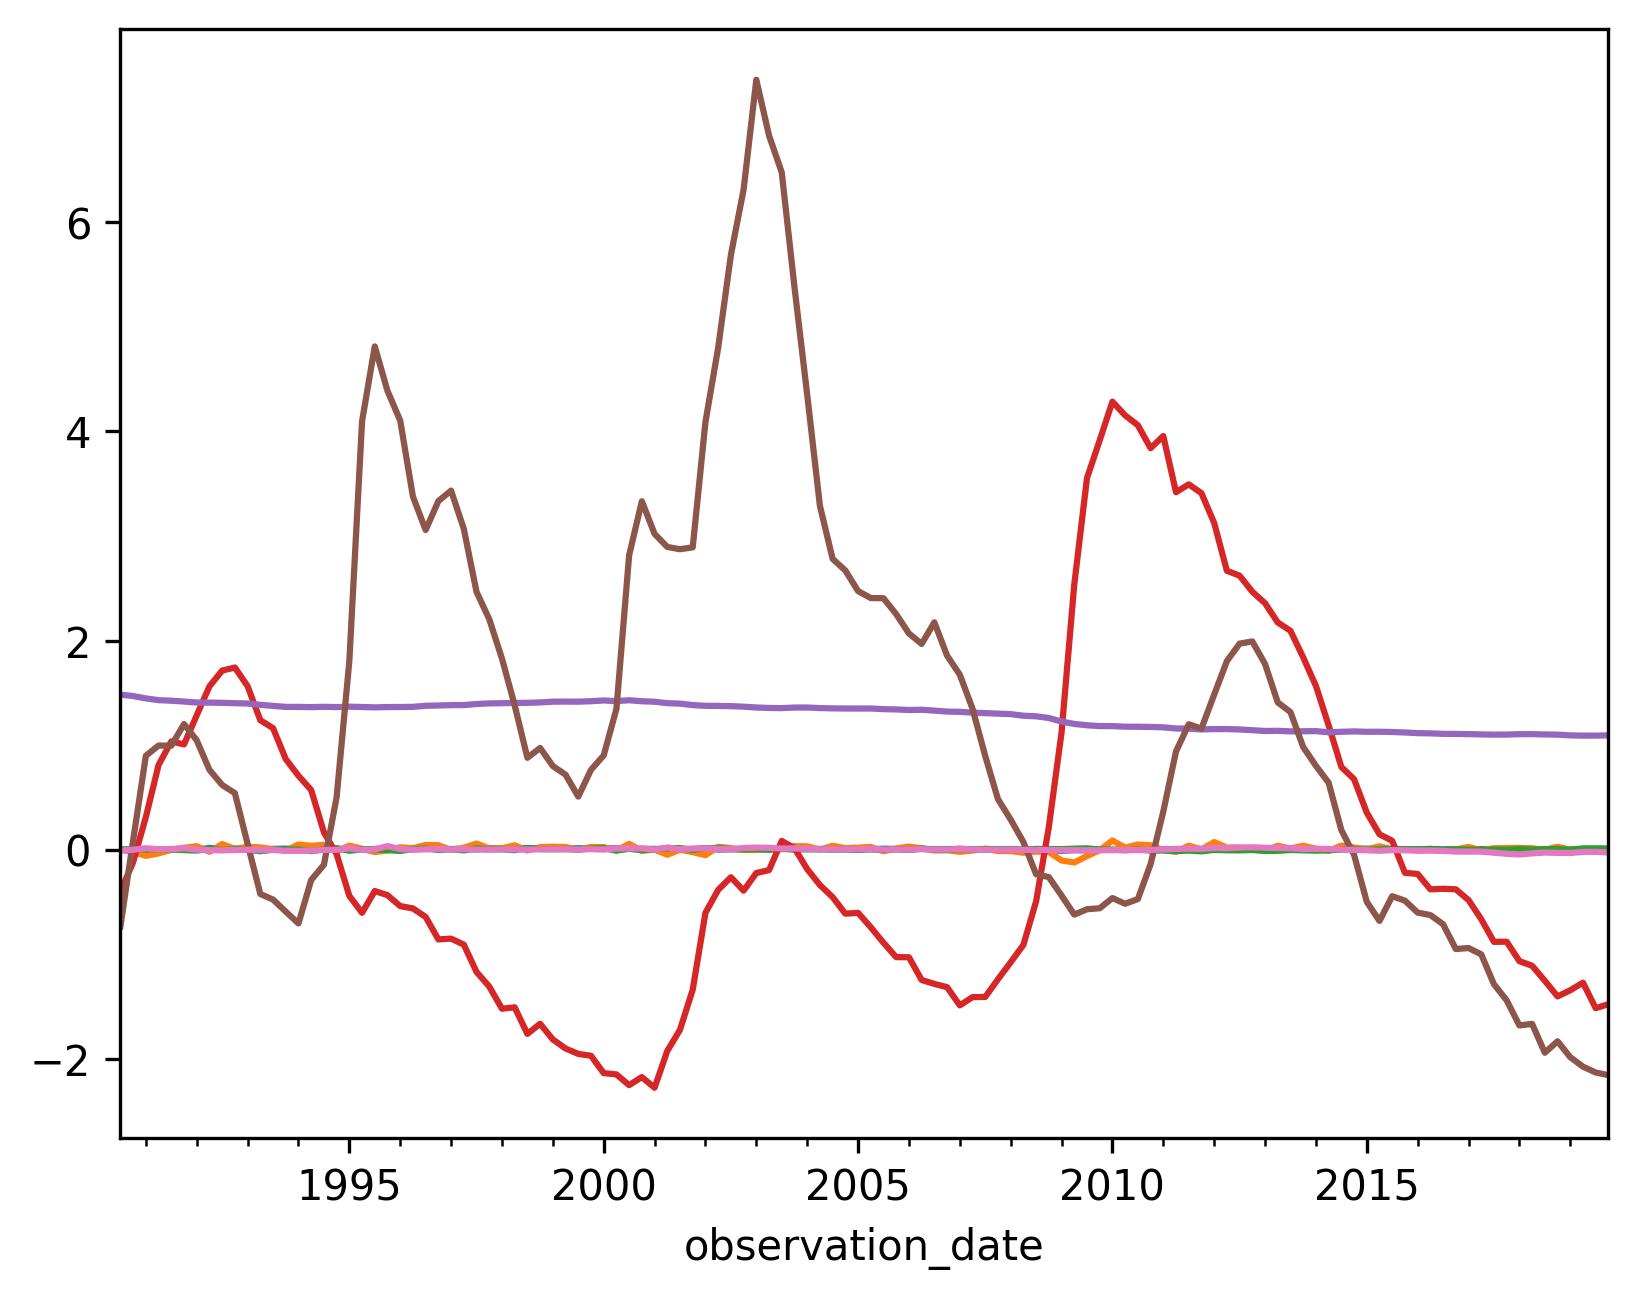

In [200]:
for v in X.columns:
    X[v].plot()